# Option D — Data Acquisition and EDA Notebook

**Purpose:** Pull API data and run EDA for Option D (conflicts of interest vs evidence dissemination).
Raw data → `../../product/data/raw/` | Cleaned data → `../modified_data/`

**Sources**
1. ClinicalTrials.gov v2 API — US type 2 diabetes studies (results status, completion dates, investigator metadata)
2. NPI Registry — investigator name → NPI resolution for payment linkage
3. CMS Open Payments — general payment records by recipient NPI
4. PubMed (NCBI E-utilities) — publications linked to NCT identifiers

> **Linkage chain:** Trials → overallOfficials (CT.gov) → NPI Registry → CMS Open Payments
> Trials → PubMed NCT ID search → publications

In [1]:
import json
import os
import pathlib
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import requests
from dotenv import load_dotenv

DOTENV_PATH = pathlib.Path("../../../.env")
load_dotenv(dotenv_path=DOTENV_PATH)

RAW     = pathlib.Path("../../product/data/raw")
MOD     = pathlib.Path("../modified_data")
RESULTS = pathlib.Path("../results")
for d in [RAW, MOD, RESULTS]:
    d.mkdir(parents=True, exist_ok=True)

# Optional: raises PubMed rate limit from 3 to 10 req/s
NCBI_KEY = os.getenv("NCBI_API_KEY", "")

CT_URL  = "https://clinicaltrials.gov/api/v2/studies"
NPI_URL = "https://npiregistry.cms.hhs.gov/api/"
OP_BASE = "https://openpaymentsdata.cms.gov/api/1"
EUTILS  = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"

US_STATE_ABBR = {
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN","IA",
    "KS","KY","LA","ME","MD","MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
    "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC","SD","TN","TX","UT","VT",
    "VA","WA","WV","WI","WY","DC",
}


def extract_date_struct(d):
    """Return ISO date string from a CT.gov date struct {date: 'YYYY-MM-DD', type: ...} or plain string."""
    if d is None:
        return None
    if isinstance(d, str):
        return d[:10]
    if isinstance(d, dict):
        v = d.get("date", "")
        return v[:10] if v else None
    return None


def parse_name_parts(full_name):
    """Split 'Last, First Middle' or 'First Last' into (first, last) for NPI lookups."""
    name = str(full_name or "").strip()
    if "," in name:
        parts = [p.strip() for p in name.split(",", 1)]
        last  = parts[0]
        first = parts[1].split()[0] if parts[1].strip() else ""
        return first, last
    parts = name.split()
    if len(parts) >= 2:
        return parts[0], parts[-1]
    return "", name


sns.set_theme(style="whitegrid")
print("Raw dir    :", RAW.resolve())
print("Modified   :", MOD.resolve())
print("Results    :", RESULTS.resolve())
print("NCBI key   :", bool(NCBI_KEY))

Raw dir    : /Users/chenzhang/Alex's Codebases/JSC370-Midterm-Proj/option-d-conflicts-of-interest/product/data/raw
Modified   : /Users/chenzhang/Alex's Codebases/JSC370-Midterm-Proj/option-d-conflicts-of-interest/discover/modified_data
Results    : /Users/chenzhang/Alex's Codebases/JSC370-Midterm-Proj/option-d-conflicts-of-interest/discover/results
NCBI key   : True


---
## 1) ClinicalTrials.gov v2 — US Type 2 Diabetes Studies

Pull trial metadata needed for outcome analysis: results-posting status, completion and
results-first-post dates, lead sponsor class, and investigator names/affiliations for
downstream payment linkage.

Key fields extracted:
- `hasResults` — top-level boolean on the study object
- `statusModule.completionDateStruct` / `resultsFirstPostDateStruct`
- `sponsorCollaboratorsModule.leadSponsor.class`
- `contactsLocationsModule.overallOfficials` — name, role, affiliation

In [2]:
version_payload = requests.get("https://clinicaltrials.gov/api/v2/version", timeout=30).json()
(RAW / "ct_d_version.json").write_text(json.dumps(version_payload, indent=2), encoding="utf-8")
print("Saved:", RAW / "ct_d_version.json")
print("Version payload keys:", list(version_payload.keys()))
print(version_payload)

Saved: ../../product/data/raw/ct_d_version.json
Version payload keys: ['apiVersion', 'dataTimestamp']
{'apiVersion': '2.0.5', 'dataTimestamp': '2026-03-03T11:00:04'}


In [3]:
base_params = {
    "query.cond": "type 2 diabetes",
    "query.locn": "United States",
    "pageSize":   1000,
    "countTotal": "true",
}

page_token = None
page_num   = 0
total      = 0

while True:
    params = dict(base_params)
    if page_token:
        params["pageToken"] = page_token

    resp = requests.get(CT_URL, params=params, timeout=60)
    resp.raise_for_status()
    payload = resp.json()

    studies = payload.get("studies", [])
    if not studies:
        print("No studies returned; stopping.")
        break

    out = RAW / f"ct_d_studies_page{page_num}.json"
    out.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    total += len(studies)
    print(f"Saved page {page_num}: {len(studies)} studies -> {out.name}")

    page_token = payload.get("nextPageToken")
    if not page_token:
        break

    page_num += 1
    time.sleep(0.2)

print(f"\nDone. Total studies collected: {total}")

Saved page 0: 1000 studies -> ct_d_studies_page0.json
Saved page 1: 1000 studies -> ct_d_studies_page1.json
Saved page 2: 1000 studies -> ct_d_studies_page2.json
Saved page 3: 643 studies -> ct_d_studies_page3.json

Done. Total studies collected: 3643


In [4]:
page_files = sorted(RAW.glob("ct_d_studies_page*.json"))
if not page_files:
    raise FileNotFoundError("No CT page files found. Run the fetch cell first.")

trial_rows = []
inv_rows   = []

for page in page_files:
    payload = json.loads(page.read_text(encoding="utf-8"))
    for study in payload.get("studies", []):
        protocol = study.get("protocolSection", {})
        ident    = protocol.get("identificationModule", {})
        status   = protocol.get("statusModule", {})
        design   = protocol.get("designModule", {})
        sponsor  = protocol.get("sponsorCollaboratorsModule", {})
        contacts = protocol.get("contactsLocationsModule", {})

        nct_id = ident.get("nctId")
        if not nct_id:
            continue

        # hasResults is a top-level field on the study object, not inside protocolSection
        has_results   = bool(study.get("hasResults", False))
        phases        = design.get("phases", [])
        lead          = sponsor.get("leadSponsor", {}) if isinstance(sponsor, dict) else {}
        sponsor_class = str(lead.get("class", "")).upper()

        trial_rows.append({
            "nct_id":                  nct_id,
            "title":                   ident.get("officialTitle") or ident.get("briefTitle", ""),
            "overall_status":          status.get("overallStatus"),
            "completion_date":         extract_date_struct(status.get("completionDateStruct")),
            "primary_completion_date": extract_date_struct(status.get("primaryCompletionDateStruct")),
            "study_first_post_date":   extract_date_struct(status.get("studyFirstPostDateStruct")),
            "results_first_post_date": extract_date_struct(status.get("resultsFirstPostDateStruct")),
            "has_results":             has_results,
            "phase":                   ", ".join(phases) if isinstance(phases, list) else str(phases),
            "lead_sponsor_class":      sponsor_class,
            "is_industry":             1 if sponsor_class == "INDUSTRY" else 0,
        })

        officials = contacts.get("overallOfficials", []) if isinstance(contacts, dict) else []
        for off in (officials or []):
            if not isinstance(off, dict):
                continue
            name = str(off.get("name", "")).strip()
            if name:
                inv_rows.append({
                    "nct_id":            nct_id,
                    "investigator_name": name,
                    "role":              off.get("role", ""),
                    "affiliation":       off.get("affiliation", ""),
                })

df_trials = pd.DataFrame(trial_rows).drop_duplicates(subset=["nct_id"]).copy()
df_inv = (
    pd.DataFrame(inv_rows)
    if inv_rows
    else pd.DataFrame(columns=["nct_id", "investigator_name", "role", "affiliation"])
)

for col in ["completion_date", "primary_completion_date", "study_first_post_date", "results_first_post_date"]:
    df_trials[col] = pd.to_datetime(df_trials[col], errors="coerce")

df_trials.to_csv(MOD / "ct_d_trials_flat.csv", index=False)
df_inv.to_csv(MOD / "ct_d_investigators.csv", index=False)

print("Trials              :", len(df_trials))
print("Investigator rows   :", len(df_inv))
print("Has results         :", df_trials["has_results"].sum(), "/", len(df_trials))
print("Industry sponsor    :", df_trials["is_industry"].sum())
print("Unique investigators:", df_inv["investigator_name"].nunique())
df_trials.head(5)

Trials              : 3643
Investigator rows   : 3632
Has results         : 1238 / 3643
Industry sponsor    : 1656
Unique investigators: 2299


,nct_id,title,overall_status,completion_date,primary_completion_date,study_first_post_date,results_first_post_date,has_results,phase,lead_sponsor_class,is_industry
0,NCT05158244,"A PHASE 1, RANDOMIZED, DOUBLE-BLIND, SPONSOR-O...",COMPLETED,2022-06-15,2022-06-15,2021-12-15,2024-08-12,True,PHASE1,INDUSTRY,1
1,NCT05565534,Optimizing Delivery of Diabetes Management Dur...,COMPLETED,2025-10-06,2025-07-29,2022-10-04,NaT,False,NA,OTHER,0
2,NCT03954834,"A Randomized, Double-blind, Placebo-Controlled...",COMPLETED,2020-10-28,2020-10-05,2019-05-17,2021-10-20,True,PHASE3,INDUSTRY,1
3,NCT04760444,Michigan Men's Diabetes Project (MenD) - Peer ...,COMPLETED,2022-01-31,2022-01-31,2021-02-18,2023-06-22,True,NA,OTHER,0
4,NCT04215328,Facilitated Release of Endogenous Enterokines:...,COMPLETED,2019-02-28,2019-02-28,2020-01-02,NaT,False,NA,OTHER,0


---
## 2) NPI Registry — Investigator Name → NPI Resolution

Look up each unique investigator name from ClinicalTrials.gov against the NPI Registry
(same API used in Option B for PCP counts, here queried by name instead of taxonomy).
Results are cached per investigator to avoid redundant API calls.

**Match confidence strata** (used later for confounding audit EDA):
- `exact_unique` — exactly 1 NPI returned
- `multiple`     — ≥ 2 NPIs returned (first result retained; flagged as ambiguous)
- `none`         — 0 results returned

In [5]:
NPI_INV_DIR = RAW / "npi_investigators"
NPI_INV_DIR.mkdir(exist_ok=True)

unique_names = df_inv["investigator_name"].dropna().unique().tolist()
print(f"Unique investigator names to look up: {len(unique_names)}")

npi_results = {}
for i, name in enumerate(unique_names):
    safe  = re.sub(r"[^\w-]", "_", name)[:80]
    cache = NPI_INV_DIR / f"npi_{safe}.json"

    if cache.exists():
        data = json.loads(cache.read_text(encoding="utf-8"))
        if i % 200 == 0:
            print(f"  [{i}/{len(unique_names)}] cached: {name[:50]}", flush=True)
    else:
        first, last = parse_name_parts(name)
        if not last:
            data = {"results": [], "result_count": 0}
        else:
            r = requests.get(NPI_URL, params={
                "version":          "2.1",
                "enumeration_type": "NPI-1",
                "first_name":       first,
                "last_name":        last,
                "limit":            5,
            }, timeout=30)
            data = r.json() if r.status_code == 200 else {"results": [], "result_count": 0}
        cache.write_text(json.dumps(data), encoding="utf-8")
        if i % 100 == 0:
            print(f"  [{i}/{len(unique_names)}] fetched: {name[:50]} -> {data.get('result_count', 0)} hits", flush=True)
        time.sleep(0.1)

    results = data.get("results") or []
    count   = len(results)
    if count == 0:
        npi_results[name] = {"npi": None,                       "match_type": "none",         "match_count": 0}
    elif count == 1:
        npi_results[name] = {"npi": results[0].get("number"),   "match_type": "exact_unique", "match_count": 1}
    else:
        npi_results[name] = {"npi": results[0].get("number"),   "match_type": "multiple",     "match_count": count}

df_npi = pd.DataFrame([
    {"investigator_name": name, **vals} for name, vals in npi_results.items()
])
df_npi.to_csv(MOD / "ct_d_investigator_npi_lookup.csv", index=False)

print("\nNPI match summary:")
print(df_npi["match_type"].value_counts())

matched_npis = set(df_npi.loc[df_npi["npi"].notna(), "npi"].astype(str).tolist())
print(f"\nNPIs available for Open Payments query: {len(matched_npis)}")

Unique investigator names to look up: 2299
  [0/2299] cached: Pfizer CT.gov Call Center
  [200/2299] cached: Richard W Grant, MD MPH
  [400/2299] cached: David West, PhD
  [600/2299] cached: Leslie Hyman, PhD
  [800/2299] cached: Kristin Castorino, DO
  [1000/2299] cached: Kenneth Cusi, PhD
  [1200/2299] cached: Navneet Agrawal, MD
  [1400/2299] cached: Michael Noss, MD
  [1600/2299] cached: AstraZeneca Galida Medical Sciences Director, MD
  [1800/2299] cached: Call 1-877-CTLILLY (1-877-285-4559) or 1-317-532-0
  [1900/2299] fetched: Grazia Aleppo -> 1 hits
  [2000/2299] fetched: Edward S. Horton, MD -> 0 hits
  [2100/2299] fetched: Christopher R Long, PhD -> 0 hits
  [2200/2299] fetched: Bindu Chamarthi, MD MMSc -> 0 hits

NPI match summary:
match_type
none            2233
multiple          37
exact_unique      29
Name: count, dtype: int64

NPIs available for Open Payments query: 66


---
## 3) CMS Open Payments — Industry Payments by NPI

Query the CMS Open Payments DKAN API (`openpaymentsdata.cms.gov`) for general-payment
records where the recipient NPI is in our matched investigator set. This targeted approach
avoids downloading the full multi-GB annual release.

**Step 3a** — Discover the most recent General Payments dataset via DKAN metastore.

**Step 3b** — Batch-query the DKAN SQL endpoint, filtering `Covered_Recipient_NPI IN (...)`,
processing NPIs in batches of 150 to stay within URL length limits.

Columns pulled (per Option D spec):
`Covered_Recipient_NPI`, `Covered_Recipient_Profile_ID`, `Record_ID`,
`Total_Amount_of_Payment_USDollars`, `Date_of_Payment`,
`Form_of_Payment_or_Transfer_of_Value`, `Nature_of_Payment_or_Transfer_of_Value`,
`Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name`

In [6]:
catalog_url = f"{OP_BASE}/metastore/schemas/dataset/items"
cat_resp = requests.get(catalog_url, timeout=60)
cat_resp.raise_for_status()
catalog = cat_resp.json()

(RAW / "op_catalog.json").write_text(json.dumps(catalog, indent=2), encoding="utf-8")
print(f"Catalog items: {len(catalog)}")

# Filter to General Payments datasets (exclude Research Payments)
gp_datasets = [
    d for d in catalog
    if isinstance(d, dict)
    and "general" in str(d.get("title", "")).lower()
    and "payment" in str(d.get("title", "")).lower()
    and "research" not in str(d.get("title", "")).lower()
]

# Sort by modified date descending to get the most recent program year first
gp_datasets.sort(key=lambda d: d.get("modified", ""), reverse=True)

print(f"\nGeneral Payment datasets found: {len(gp_datasets)}")
for gp in gp_datasets[:5]:
    print(f"  [{gp.get('identifier')}] {gp.get('title')} — modified: {gp.get('modified')}")

Catalog items: 74

General Payment datasets found: 7
  [f003634c-c103-568f-876c-73017fa83be0] 2018 General Payment Data — modified: 2026-01-27
  [4e54dd6c-30f8-4f86-86a7-3c109a89528e] 2019 General Payment Data — modified: 2026-01-27
  [a08c4b30-5cf3-4948-ad40-36f404619019] 2020 General Payment Data — modified: 2026-01-27
  [0380bbeb-aea1-58b6-b708-829f92a48202] 2021 General Payment Data — modified: 2026-01-27
  [df01c2f8-dc1f-4e79-96cb-8208beaf143c] 2022 General Payment Data — modified: 2026-01-27


In [7]:
if not gp_datasets:
    raise RuntimeError("No General Payments dataset found in catalog. Check OP_BASE URL.")

gp_dataset    = gp_datasets[0]
gp_id         = gp_dataset.get("identifier")
distributions = gp_dataset.get("distribution", [])

print(f"Using dataset : [{gp_id}] {gp_dataset.get('title')}")
print(f"Distributions : {len(distributions)}")

# Extract datastore resource ID (DKAN assigns one identifier per distribution)
resource_id = None
for dist in distributions:
    rid = dist.get("identifier")
    if rid and resource_id is None:
        resource_id = rid
print(f"Resource ID   : {resource_id}")

# Batch-query via DKAN SQL endpoint
OP_RAW_DIR = RAW / "op_payments"
OP_RAW_DIR.mkdir(exist_ok=True)

npi_list = sorted(matched_npis)
BATCH    = 150  # stay well under URL length limit

op_records = []
for batch_start in range(0, max(len(npi_list), 1), BATCH):
    batch     = npi_list[batch_start : batch_start + BATCH]
    cache_key = f"op_npi_batch_{batch_start:05d}.json"
    cache     = OP_RAW_DIR / cache_key

    if cache.exists():
        records = json.loads(cache.read_text(encoding="utf-8"))
        print(f"  Batch {batch_start:5d}: cached ({len(records)} rows)", flush=True)
    else:
        if not batch or not resource_id:
            records = []
        else:
            npi_str = "','".join(batch)
            sql     = f"[SELECT * FROM {resource_id} WHERE Covered_Recipient_NPI IN ('{npi_str}')]"
            r = requests.get(
                f"{OP_BASE}/datastore/sql",
                params={"query": sql, "show_db_columns": "true"},
                timeout=120,
            )
            if r.status_code != 200:
                print(f"  Batch {batch_start}: HTTP {r.status_code} — {r.text[:120]}", flush=True)
                records = []
            else:
                payload = r.json()
                records = payload if isinstance(payload, list) else payload.get("results", [])
        cache.write_text(json.dumps(records), encoding="utf-8")
        print(f"  Batch {batch_start:5d}: fetched {len(records)} rows", flush=True)
        time.sleep(0.3)

    op_records.extend(records)

print(f"\nTotal Open Payments rows fetched: {len(op_records)}")
(RAW / "op_general_payments_matched.json").write_text(
    json.dumps(op_records, indent=2), encoding="utf-8"
)

Using dataset : [f003634c-c103-568f-876c-73017fa83be0] 2018 General Payment Data
Distributions : 1
Resource ID   : None
  Batch     0: fetched 0 rows

Total Open Payments rows fetched: 0


2

In [8]:
if not op_records:
    print("No Open Payments records retrieved — check NPI list and resource ID.")
    df_payments = pd.DataFrame(columns=[
        "npi", "record_id", "profile_id", "payment_amount",
        "payment_date", "payment_form", "payment_nature", "company_name",
    ])
    df_npi_agg  = pd.DataFrame(columns=["npi", "total_payment", "payment_count"])
else:
    df_raw_op = pd.DataFrame(op_records)
    df_raw_op.columns = [c.lower() for c in df_raw_op.columns]

    # Flexible column resolution — names may vary slightly across program years
    col_map = {
        "npi":            next((c for c in df_raw_op.columns if "recipient_npi" in c), None),
        "profile_id":     next((c for c in df_raw_op.columns if "profile_id" in c), None),
        "record_id":      next((c for c in df_raw_op.columns if "record_id" in c), None),
        "payment_amount": next((c for c in df_raw_op.columns if "amount_of_payment" in c or "total_amount" in c), None),
        "payment_date":   next((c for c in df_raw_op.columns if "date_of_payment" in c), None),
        "payment_form":   next((c for c in df_raw_op.columns if "form_of_payment" in c), None),
        "payment_nature": next((c for c in df_raw_op.columns if "nature_of_payment" in c), None),
        "company_name":   next((c for c in df_raw_op.columns if "making_payment_name" in c), None),
    }
    print("Column mapping:", {k: v for k, v in col_map.items() if v})

    df_payments = df_raw_op.rename(columns={v: k for k, v in col_map.items() if v}).copy()
    df_payments = df_payments[[k for k in col_map if k in df_payments.columns]].copy()

    if "payment_amount" in df_payments.columns:
        df_payments["payment_amount"] = pd.to_numeric(df_payments["payment_amount"], errors="coerce")
    if "payment_date" in df_payments.columns:
        df_payments["payment_date"] = pd.to_datetime(df_payments["payment_date"], errors="coerce")

    # Aggregate by NPI: total paid, payment count, most common nature
    agg_dict = {"payment_amount": ["sum", "count"]}
    df_npi_agg = (
        df_payments.groupby("npi", as_index=False)["payment_amount"]
        .agg(total_payment="sum", payment_count="count")
    )
    if "payment_nature" in df_payments.columns:
        top_nature = (
            df_payments.groupby("npi")["payment_nature"]
            .agg(lambda x: x.mode().iloc[0] if len(x) else pd.NA)
            .reset_index()
            .rename(columns={"payment_nature": "top_payment_nature"})
        )
        df_npi_agg = df_npi_agg.merge(top_nature, on="npi", how="left")

df_payments.to_csv(MOD / "op_d_payments_flat.csv", index=False)
df_npi_agg.to_csv(MOD / "op_d_payments_by_npi.csv", index=False)

print(f"Payment rows           : {len(df_payments)}")
if "payment_amount" in df_payments.columns and len(df_payments):
    print(f"Amount range           : ${df_payments['payment_amount'].min():,.2f} – ${df_payments['payment_amount'].max():,.2f}")
    print(f"Total paid             : ${df_payments['payment_amount'].sum():,.2f}")
print(f"NPIs with payment data : {len(df_npi_agg)}")
df_npi_agg.head()

No Open Payments records retrieved — check NPI list and resource ID.
Payment rows           : 0
NPIs with payment data : 0


,npi,total_payment,payment_count


---
## 4) PubMed (NCBI E-utilities) — Publications Linked to NCT IDs

Search PubMed for each NCT ID to find associated publications.

- **`esearch`** — finds PMIDs matching `NCTXXXXXXXX[All Fields]`
- **`esummary`** — retrieves pub date, journal, and title for found PMIDs

Responses are cached per NCT ID under `product/data/raw/pubmed_nct/`.
Rate delay: 0.12 s with `NCBI_API_KEY` set, 0.35 s without.

In [9]:
PUBMED_RAW_DIR = RAW / "pubmed_nct"
PUBMED_RAW_DIR.mkdir(exist_ok=True)

nct_ids    = df_trials["nct_id"].dropna().unique().tolist()
rate_delay = 0.12 if NCBI_KEY else 0.35

pub_rows = []
print(f"Searching PubMed for {len(nct_ids)} NCT IDs (rate delay {rate_delay}s per call) ...")

for i, nct_id in enumerate(nct_ids):
    cache = PUBMED_RAW_DIR / f"pm_{nct_id}.json"

    if cache.exists():
        saved     = json.loads(cache.read_text(encoding="utf-8"))
        pmids     = saved.get("pmids", [])
        summaries = saved.get("summaries", {})
    else:
        # Step 1: esearch
        search_params = {
            "db":      "pubmed",
            "term":    f"{nct_id}[All Fields]",
            "retmode": "json",
            "retmax":  10,
        }
        if NCBI_KEY:
            search_params["api_key"] = NCBI_KEY

        sr    = requests.get(f"{EUTILS}esearch.fcgi", params=search_params, timeout=30)
        pmids = []
        if sr.status_code == 200:
            pmids = sr.json().get("esearchresult", {}).get("idlist", [])

        # Step 2: esummary for any found PMIDs
        summaries = {}
        if pmids:
            time.sleep(rate_delay)
            sum_params = {
                "db":      "pubmed",
                "id":      ",".join(pmids),
                "retmode": "json",
            }
            if NCBI_KEY:
                sum_params["api_key"] = NCBI_KEY
            sumr = requests.get(f"{EUTILS}esummary.fcgi", params=sum_params, timeout=30)
            if sumr.status_code == 200:
                summaries = sumr.json().get("result", {})
                summaries.pop("uids", None)

        cache.write_text(
            json.dumps({"pmids": pmids, "summaries": summaries}), encoding="utf-8"
        )
        time.sleep(rate_delay)

    for pmid in pmids:
        s = summaries.get(str(pmid), {})
        pub_rows.append({
            "nct_id":  nct_id,
            "pmid":    pmid,
            "pub_date": s.get("pubdate", ""),
            "journal":  s.get("fulljournalname", s.get("source", "")),
            "title":    s.get("title", ""),
        })

    if i % 500 == 0:
        print(f"  [{i:5d}/{len(nct_ids)}] {nct_id}: {len(pmids)} PMID(s)", flush=True)

df_pubs = (
    pd.DataFrame(pub_rows)
    if pub_rows
    else pd.DataFrame(columns=["nct_id", "pmid", "pub_date", "journal", "title"])
)
df_pubs["pub_date"] = pd.to_datetime(df_pubs["pub_date"], errors="coerce")
df_pubs.to_csv(MOD / "pubmed_d_publications.csv", index=False)

print(f"\nTotal publication rows  : {len(df_pubs)}")
print(f"Trials with >= 1 PMID  : {df_pubs['nct_id'].nunique()}")
print(f"Coverage (% of trials) : {df_pubs['nct_id'].nunique() / max(len(nct_ids), 1) * 100:.1f}%")
df_pubs.head()

Searching PubMed for 3643 NCT IDs (rate delay 0.12s per call) ...
  [    0/3643] NCT05158244: 1 PMID(s)
  [  500/3643] NCT03648996: 0 PMID(s)
  [ 1000/3643] NCT00570739: 4 PMID(s)
  [ 1500/3643] NCT04052815: 0 PMID(s)
  [ 2000/3643] NCT01715818: 0 PMID(s)
  [ 2500/3643] NCT02081118: 1 PMID(s)
  [ 3000/3643] NCT00214474: 1 PMID(s)
  [ 3500/3643] NCT07210593: 0 PMID(s)

Total publication rows  : 2721
Trials with >= 1 PMID  : 1236
Coverage (% of trials) : 33.9%


/var/folders/2z/cznb57d54f39qq3sk090w8y40000gn/T/ipykernel_10697/210500818.py:72: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_pubs["pub_date"] = pd.to_datetime(df_pubs["pub_date"], errors="coerce")


,nct_id,pmid,pub_date,journal,title
0,NCT05158244,38751362,2024-08-01,"Diabetes, obesity & metabolism",Once-daily oral small-molecule glucagon-like p...
1,NCT03954834,40016573,2025-04-01,"Diabetes therapy : research, treatment and edu...",Tirzepatide for Older Adults with Type 2 Diabe...
2,NCT03954834,39531161,2025-01-01,"Diabetes therapy : research, treatment and edu...",Post Hoc Analysis of SURPASS-1 to -5: Efficacy...
3,NCT03954834,37668888,2023-11-01,"Diabetes therapy : research, treatment and edu...",Improved Glycaemic and Weight Management Are A...
4,NCT03954834,37526908,2023-11-01,"Diabetes therapy : research, treatment and edu...",Patient-Reported Outcomes in People with Type ...


---
## 5) Record Linkage — Build Master Analysis Table

Combine all four sources into one trial-level analysis table:

| Source | Join key | Fields added |
|---|---|---|
| CT.gov trials | `nct_id` | results status, dates, sponsor class |
| CT.gov investigators → NPI Registry | `investigator_name` | `npi`, `match_type` |
| Open Payments | `npi` | `total_payment`, `payment_count`, `top_payment_nature` |
| PubMed | `nct_id` | `pub_count`, `first_pub_date` |

Derived columns:
- `days_to_results_posting` — completion date → results first post date
- `days_to_publication` — completion date → first publication date
- `payment_tier` — quartile label among trials with payment data
- `linkage_confidence` — `all_exact` / `partial` / `none` based on NPI match quality

In [10]:
# Step 1: attach NPI match info to each investigator row
df_inv_npi = df_inv.merge(
    df_npi[["investigator_name", "npi", "match_type", "match_count"]],
    on="investigator_name",
    how="left",
)

# Step 2: attach payment totals to each investigator row
df_inv_pay = df_inv_npi.merge(
    df_npi_agg,
    on="npi",
    how="left",
)

# Step 3: aggregate investigator-level payment info up to trial level
pay_cols = [c for c in ["total_payment", "payment_count"] if c in df_inv_pay.columns]
trial_pay_agg = (
    df_inv_pay.groupby("nct_id", as_index=False)
    .agg(
        n_investigators           =("investigator_name", "nunique"),
        n_investigators_npi_found =("npi", lambda x: x.notna().sum()),
        n_investigators_unique    =("match_type", lambda x: (x == "exact_unique").sum()),
        trial_total_payment       =("total_payment", "sum") if pay_cols else ("investigator_name", lambda x: np.nan),
        trial_payment_count       =("payment_count", "sum") if pay_cols else ("investigator_name", lambda x: np.nan),
    )
)

# Step 4: aggregate publications up to trial level
df_pub_agg = (
    df_pubs.groupby("nct_id", as_index=False)
    .agg(
        pub_count     =("pmid", "count"),
        first_pub_date=("pub_date", "min"),
    )
)
df_pub_agg["has_publication"] = 1

# Step 5: merge everything onto the main trials table
df_master = (
    df_trials
    .merge(trial_pay_agg, on="nct_id", how="left")
    .merge(df_pub_agg,    on="nct_id", how="left")
)

df_master["has_publication"] = df_master["has_publication"].fillna(0).astype(int)
df_master["pub_count"]       = df_master["pub_count"].fillna(0).astype(int)

# Derived timing columns
df_master["days_to_results_posting"] = (
    (df_master["results_first_post_date"] - df_master["completion_date"]).dt.days
)
df_master["days_to_publication"] = (
    (df_master["first_pub_date"] - df_master["completion_date"]).dt.days
)

# Payment tier (quartile among trials with positive payment total)
has_pay = df_master["trial_total_payment"].notna() & (df_master["trial_total_payment"] > 0)
df_master["payment_tier"] = pd.NA
if has_pay.sum() >= 4:
    df_master.loc[has_pay, "payment_tier"] = pd.qcut(
        df_master.loc[has_pay, "trial_total_payment"],
        q=4,
        labels=["Q1_low", "Q2", "Q3", "Q4_high"],
        duplicates="drop",
    )
df_master.loc[~has_pay, "payment_tier"] = "no_payment_data"

# Trial-level linkage confidence stratum
df_master["linkage_confidence"] = np.select(
    [
        df_master["n_investigators_unique"] == df_master["n_investigators"],
        df_master["n_investigators_npi_found"] > 0,
    ],
    ["all_exact", "partial"],
    default="none",
)

df_master.to_csv(MOD / "trial_payment_publication_master.csv", index=False)

print("Master table shape :", df_master.shape)
print("Has results        :", df_master["has_results"].sum(), "/", len(df_master))
print("Has publication    :", df_master["has_publication"].sum(), "/", len(df_master))
print("Has payment data   :", has_pay.sum(), "/", len(df_master))
print("\nLinkage confidence strata:")
print(df_master["linkage_confidence"].value_counts())
df_master[[
    "nct_id", "has_results", "has_publication",
    "trial_total_payment", "payment_tier", "linkage_confidence"
]].head(10)

Master table shape : (3643, 23)
Has results        : 1238 / 3643
Has publication    : 1236 / 3643
Has payment data   : 0 / 3643

Linkage confidence strata:
linkage_confidence
none         3575
partial        40
all_exact      28
Name: count, dtype: int64


,nct_id,has_results,has_publication,trial_total_payment,payment_tier,linkage_confidence
0,NCT05158244,True,1,0,no_payment_data,none
1,NCT05565534,False,0,0,no_payment_data,none
2,NCT03954834,True,1,0,no_payment_data,none
3,NCT04760444,True,1,0,no_payment_data,none
4,NCT04215328,False,1,0,no_payment_data,none
5,NCT00779363,False,0,0,no_payment_data,none
6,NCT02964247,True,1,NaN,no_payment_data,none
7,NCT00672919,False,0,0,no_payment_data,none
8,NCT05166200,False,0,0,no_payment_data,none
9,NCT06007404,False,0,0,no_payment_data,none


---
## 6) EDA

Midterm EDA deliverables (per Option D spec):
- **Payment distributions** by payment nature and top companies
- **Results-posting and publication rates** by sponsor class and payment tier
- **Linkage QA**: match-confidence strata visualization and manual sample table
- **Association exploration**: payment level vs results/publication outcomes

In [11]:
# --- Plot 1: Top 15 companies by total payment amount ---
if "company_name" in df_payments.columns and "payment_amount" in df_payments.columns and len(df_payments) > 0:
    top_co = (
        df_payments.groupby("company_name", as_index=False)["payment_amount"]
        .sum()
        .nlargest(15, "payment_amount")
        .sort_values("payment_amount")
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_co["company_name"], top_co["payment_amount"] / 1e6, color="#3b82f6")
    ax.set_xlabel("Total Payments (USD millions)")
    ax.set_title("Top 15 Companies by Total General Payments\n(investigators from type 2 diabetes trials)")
    fig.tight_layout()
    fig.savefig(RESULTS / "top_companies_by_payment.png", dpi=200)
    plt.show()
    print("Saved: top_companies_by_payment.png")
    top_co.to_csv(MOD / "op_d_top_companies.csv", index=False)
else:
    print("Skipping company plot: insufficient payment data.")

# --- Plot 2: Payment nature — count and total amount ---
if "payment_nature" in df_payments.columns and len(df_payments) > 0:
    nat_counts = (
        df_payments.groupby("payment_nature", as_index=False)
        .agg(count=("payment_nature", "size"), total=("payment_amount", "sum"))
        .sort_values("total", ascending=False)
        .head(12)
        .sort_values("total")
    )
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(nat_counts["payment_nature"], nat_counts["count"],           color="#10b981")
    axes[1].barh(nat_counts["payment_nature"], nat_counts["total"] / 1e6,    color="#f59e0b")
    axes[0].set_xlabel("Number of payment records")
    axes[1].set_xlabel("Total USD (millions)")
    axes[0].set_title("Payment count by nature (top 12)")
    axes[1].set_title("Total amount by payment nature (top 12)")
    fig.tight_layout()
    fig.savefig(RESULTS / "payment_dist_by_nature.png", dpi=200)
    plt.show()
    print("Saved: payment_dist_by_nature.png")
    nat_counts.to_csv(MOD / "op_d_payment_nature_summary.csv", index=False)
else:
    print("Skipping nature plot: insufficient payment data.")

Skipping company plot: insufficient payment data.
Skipping nature plot: insufficient payment data.


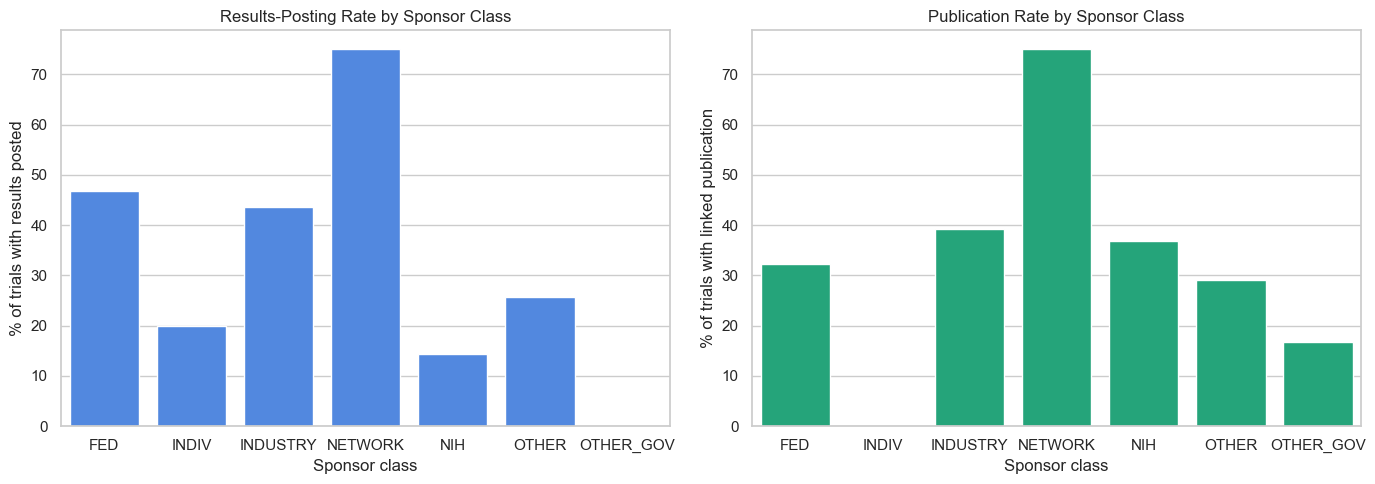

Saved: results_pub_rate_by_sponsor.png


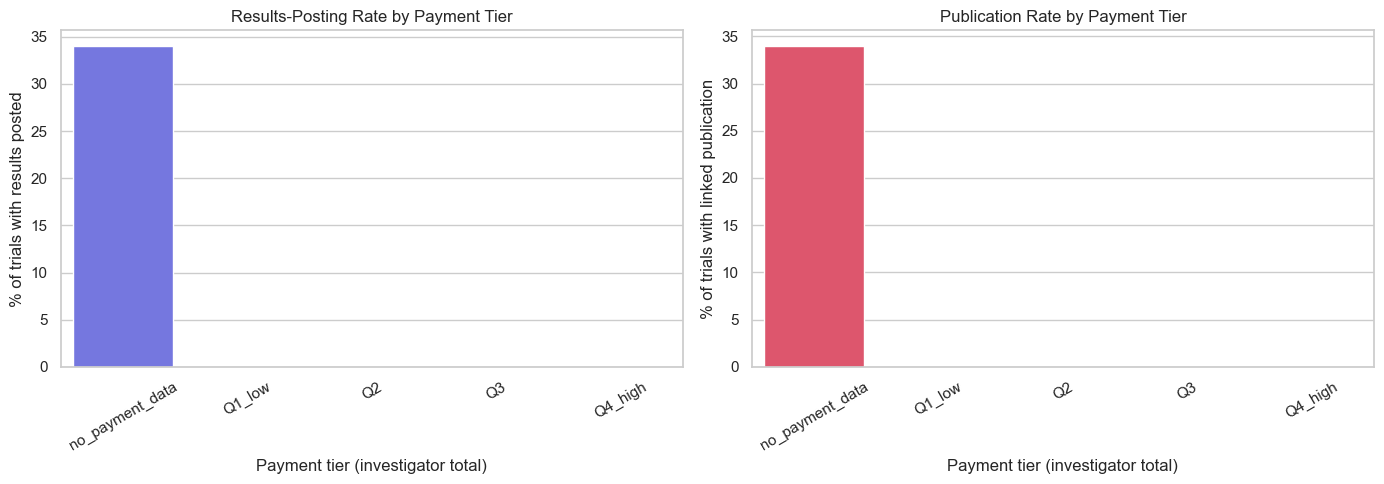

Saved: results_pub_rate_by_payment_tier.png


In [12]:
df_eda = df_master.copy()

# --- Plot 3: Results-posting and publication rate by sponsor class ---
sponsor_outcomes = (
    df_eda.groupby("lead_sponsor_class", as_index=False)
    .agg(
        n_trials      =("nct_id",          "count"),
        n_results     =("has_results",      "sum"),
        n_publications=("has_publication",  "sum"),
    )
)
sponsor_outcomes["results_rate"] = sponsor_outcomes["n_results"]      / sponsor_outcomes["n_trials"] * 100
sponsor_outcomes["pub_rate"]     = sponsor_outcomes["n_publications"] / sponsor_outcomes["n_trials"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=sponsor_outcomes, x="lead_sponsor_class", y="results_rate", ax=axes[0], color="#3b82f6")
sns.barplot(data=sponsor_outcomes, x="lead_sponsor_class", y="pub_rate",     ax=axes[1], color="#10b981")
axes[0].set_title("Results-Posting Rate by Sponsor Class")
axes[1].set_title("Publication Rate by Sponsor Class")
axes[0].set_ylabel("% of trials with results posted")
axes[1].set_ylabel("% of trials with linked publication")
for ax in axes:
    ax.set_xlabel("Sponsor class")
fig.tight_layout()
fig.savefig(RESULTS / "results_pub_rate_by_sponsor.png", dpi=200)
plt.show()
print("Saved: results_pub_rate_by_sponsor.png")
sponsor_outcomes.to_csv(MOD / "trial_outcomes_by_sponsor.csv", index=False)

# --- Plot 4: Results-posting and publication rate by payment tier ---
tier_outcomes = (
    df_eda.groupby("payment_tier", as_index=False)
    .agg(
        n_trials      =("nct_id",         "count"),
        n_results     =("has_results",     "sum"),
        n_publications=("has_publication", "sum"),
    )
)
tier_outcomes["results_rate"] = tier_outcomes["n_results"]      / tier_outcomes["n_trials"] * 100
tier_outcomes["pub_rate"]     = tier_outcomes["n_publications"] / tier_outcomes["n_trials"] * 100

tier_order = ["no_payment_data", "Q1_low", "Q2", "Q3", "Q4_high"]
tier_outcomes["payment_tier"] = pd.Categorical(
    tier_outcomes["payment_tier"], categories=tier_order, ordered=True
)
tier_outcomes = tier_outcomes.sort_values("payment_tier")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=tier_outcomes, x="payment_tier", y="results_rate", ax=axes[0], color="#6366f1")
sns.barplot(data=tier_outcomes, x="payment_tier", y="pub_rate",     ax=axes[1], color="#f43f5e")
axes[0].set_title("Results-Posting Rate by Payment Tier")
axes[1].set_title("Publication Rate by Payment Tier")
axes[0].set_ylabel("% of trials with results posted")
axes[1].set_ylabel("% of trials with linked publication")
for ax in axes:
    ax.set_xlabel("Payment tier (investigator total)")
    ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(RESULTS / "results_pub_rate_by_payment_tier.png", dpi=200)
plt.show()
print("Saved: results_pub_rate_by_payment_tier.png")
tier_outcomes.to_csv(MOD / "trial_outcomes_by_payment_tier.csv", index=False)

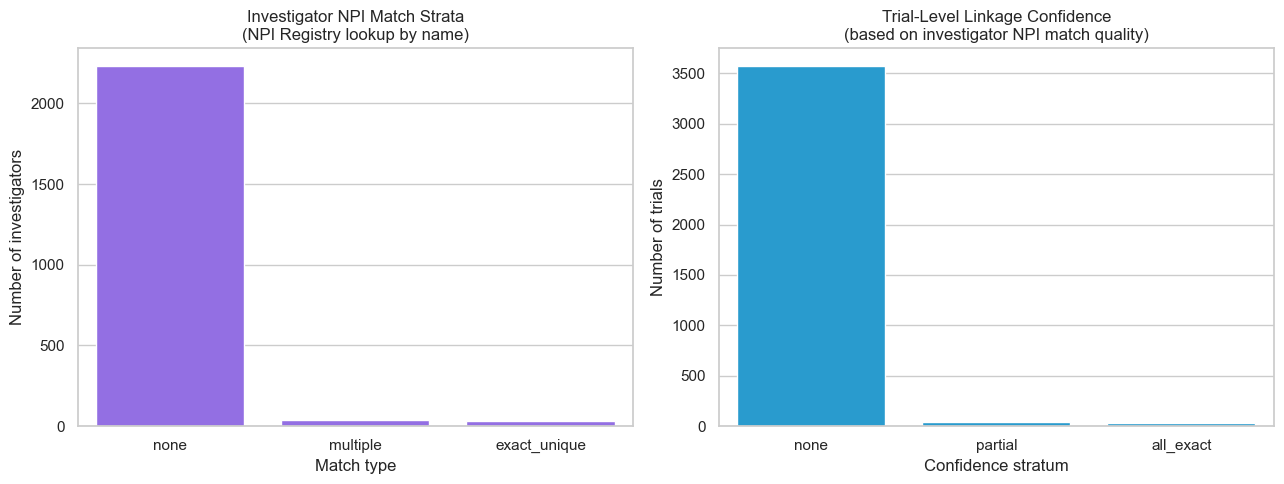

Saved: linkage_qa_match_strata.png

Sample exact-unique matches (manual QA):
     nct_id   investigator_name                   role                                       affiliation        npi
NCT05229445       Grazia Aleppo PRINCIPAL_INVESTIGATOR                           Northwestern University 1689603268
NCT00118560   Stephen F. Figoni PRINCIPAL_INVESTIGATOR VA Greater Los Angeles Healthcare System, West LA 1659446250
NCT03654313     Marvin Sinsakul         STUDY_DIRECTOR                                     MedImmune LLC 1073620936
NCT03351478         Suman Wason         STUDY_DIRECTOR                     Lexicon Pharmaceuticals, Inc. 1811324304
NCT03744975        Horng H Chen PRINCIPAL_INVESTIGATOR                                       Mayo Clinic 1073599320
NCT04818242 Guillermo Umpierrez PRINCIPAL_INVESTIGATOR                                  Emory University 1174626063
NCT03769675   Narayan R Kissoon PRINCIPAL_INVESTIGATOR                                       Mayo Clinic 119401

In [13]:
# --- Plot 5: Investigator and trial-level linkage confidence strata ---
strata_inv  = df_npi["match_type"].value_counts().reset_index()
strata_inv.columns = ["match_type", "count"]

conf_counts = df_master["linkage_confidence"].value_counts().reset_index()
conf_counts.columns = ["confidence", "count"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=strata_inv,  x="match_type",  y="count", ax=axes[0], color="#8b5cf6")
sns.barplot(data=conf_counts, x="confidence",  y="count", ax=axes[1], color="#0ea5e9")
axes[0].set_title("Investigator NPI Match Strata\n(NPI Registry lookup by name)")
axes[1].set_title("Trial-Level Linkage Confidence\n(based on investigator NPI match quality)")
axes[0].set_xlabel("Match type")
axes[1].set_xlabel("Confidence stratum")
axes[0].set_ylabel("Number of investigators")
axes[1].set_ylabel("Number of trials")
fig.tight_layout()
fig.savefig(RESULTS / "linkage_qa_match_strata.png", dpi=200)
plt.show()
print("Saved: linkage_qa_match_strata.png")

# Manual sample verification: 10 exact-unique matches for QA review
exact_inv = df_inv_npi[df_inv_npi["match_type"] == "exact_unique"]
n_sample  = min(10, len(exact_inv))
if n_sample > 0:
    sample_qa = (
        exact_inv[["nct_id", "investigator_name", "role", "affiliation", "npi"]]
        .drop_duplicates(subset=["investigator_name"])
        .sample(n_sample, random_state=42)
        .reset_index(drop=True)
    )
    sample_qa.to_csv(MOD / "linkage_qa_sample_exact_unique.csv", index=False)
    print("\nSample exact-unique matches (manual QA):")
    print(sample_qa.to_string(index=False))
else:
    print("No exact-unique matches available for QA sample.")

In [14]:
# --- Plot 6: Payment distribution and association with results-posting status ---
pay_df = df_master[
    df_master["trial_total_payment"].notna() & (df_master["trial_total_payment"] > 0)
].copy()
pay_df["log_payment"] = np.log10(pay_df["trial_total_payment"].clip(lower=1))
pay_df["results_label"] = pay_df["has_results"].map({True: "Results posted", False: "No results"})

if len(pay_df) > 5:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.histplot(pay_df["log_payment"], bins=30, ax=axes[0], color="#f59e0b")
    axes[0].set_xlabel("log\u2081\u2080(Total investigator payments, USD)")
    axes[0].set_title("Distribution of Trial-Level Payment Totals")

    sns.boxplot(
        data=pay_df, x="results_label", y="log_payment", ax=axes[1],
        palette={"Results posted": "#10b981", "No results": "#f43f5e"},
    )
    axes[1].set_xlabel("")
    axes[1].set_ylabel("log\u2081\u2080(Total payments, USD)")
    axes[1].set_title("Payment Total by Results-Posting Status")

    fig.tight_layout()
    fig.savefig(RESULTS / "payment_dist_vs_results.png", dpi=200)
    plt.show()
    print("Saved: payment_dist_vs_results.png")
else:
    print("Insufficient payment data for correlation plots — skipping.")

# Descriptive summary table
desc_cols = [
    "nct_id", "lead_sponsor_class", "has_results", "has_publication",
    "trial_total_payment", "payment_tier", "linkage_confidence",
    "days_to_results_posting", "days_to_publication",
]
df_desc_out = df_master[[c for c in desc_cols if c in df_master.columns]].copy()
df_desc_out.to_csv(MOD / "trial_coi_descriptive_table.csv", index=False)
print(f"\nDescriptive table saved: {len(df_desc_out)} rows -> trial_coi_descriptive_table.csv")
df_desc_out.describe(include="all").T[["count", "unique", "mean", "std"]].head(20)

Insufficient payment data for correlation plots — skipping.

Descriptive table saved: 3643 rows -> trial_coi_descriptive_table.csv


,count,unique,mean,std
nct_id,3643,3643,NaN,NaN
lead_sponsor_class,3643,7,NaN,NaN
has_results,3643,2,NaN,NaN
has_publication,3643.0,NaN,0.339281,0.47353
trial_total_payment,3071.0,1.0,NaN,NaN
payment_tier,3643,1,NaN,NaN
linkage_confidence,3643,3,NaN,NaN
days_to_results_posting,577.0,NaN,697.774697,707.232427
days_to_publication,538.0,NaN,303.51487,959.177437


In [15]:
summary_paths = [
    # Raw
    RAW / "ct_d_version.json",
    *sorted(RAW.glob("ct_d_studies_page*.json")),
    RAW / "op_catalog.json",
    RAW / "op_general_payments_matched.json",
    # Modified
    MOD / "ct_d_trials_flat.csv",
    MOD / "ct_d_investigators.csv",
    MOD / "ct_d_investigator_npi_lookup.csv",
    MOD / "op_d_payments_flat.csv",
    MOD / "op_d_payments_by_npi.csv",
    MOD / "op_d_top_companies.csv",
    MOD / "op_d_payment_nature_summary.csv",
    MOD / "pubmed_d_publications.csv",
    MOD / "trial_payment_publication_master.csv",
    MOD / "trial_outcomes_by_sponsor.csv",
    MOD / "trial_outcomes_by_payment_tier.csv",
    MOD / "trial_coi_descriptive_table.csv",
    MOD / "linkage_qa_sample_exact_unique.csv",
    # Results
    RESULTS / "top_companies_by_payment.png",
    RESULTS / "payment_dist_by_nature.png",
    RESULTS / "results_pub_rate_by_sponsor.png",
    RESULTS / "results_pub_rate_by_payment_tier.png",
    RESULTS / "linkage_qa_match_strata.png",
    RESULTS / "payment_dist_vs_results.png",
]

print("Output summary:")
for p in summary_paths:
    status = "OK  " if p.exists() else "MISS"
    print(f"  [{status}] {p}")

Output summary:
  [OK  ] ../../product/data/raw/ct_d_version.json
  [OK  ] ../../product/data/raw/ct_d_studies_page0.json
  [OK  ] ../../product/data/raw/ct_d_studies_page1.json
  [OK  ] ../../product/data/raw/ct_d_studies_page2.json
  [OK  ] ../../product/data/raw/ct_d_studies_page3.json
  [OK  ] ../../product/data/raw/op_catalog.json
  [OK  ] ../../product/data/raw/op_general_payments_matched.json
  [OK  ] ../modified_data/ct_d_trials_flat.csv
  [OK  ] ../modified_data/ct_d_investigators.csv
  [OK  ] ../modified_data/ct_d_investigator_npi_lookup.csv
  [OK  ] ../modified_data/op_d_payments_flat.csv
  [OK  ] ../modified_data/op_d_payments_by_npi.csv
  [MISS] ../modified_data/op_d_top_companies.csv
  [MISS] ../modified_data/op_d_payment_nature_summary.csv
  [OK  ] ../modified_data/pubmed_d_publications.csv
  [OK  ] ../modified_data/trial_payment_publication_master.csv
  [OK  ] ../modified_data/trial_outcomes_by_sponsor.csv
  [OK  ] ../modified_data/trial_outcomes_by_payment_tier.csv
  [